In [1]:
!pip install astroML

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as s
from scipy.interpolate import interp1d
from scipy.optimize import brentq

In [3]:
from urllib.request import urlretrieve

In [4]:
urlretrieve("https://das.sdss.org/va/qsocat/dr7qso.dat", './drsqso.dat')

('./drsqso.dat', <http.client.HTTPMessage at 0x22908e95950>)

In [5]:
# There are 80 header lines, skip them. The redfshift is in column 3. 
#Careful that there's another z feature, but that refers to the SDSS z filter, not the redshift
z= np.loadtxt('dr7qso.dat',skiprows=80, usecols=3)

In [25]:
counts, bin_edges = np.histogram(z)
bincenters = bin_edges[]

In [9]:
def get_experimental_pdf(counts, bin_centers):
    """
    Returns a function representing the linear interpolation 
    of the experimental histogram.
    """
    # kind='linear' creates the straight lines between points
    # fill_value=0 ensures that outside the data range, the PDF is zero
    # bounds_error=False prevents the code from crashing if you ask for a z outside the range
    pdf_func = interp1d(bin_centers, counts, 
                        kind='linear', 
                        bounds_error=False, 
                        fill_value=0.0)
    return pdf_func


# 3. Use it to find the density at a specific redshift (e.g., z=1.8)
density_at_1_8 = f_z(1.8)
print(f"The experimental PDF value at z=1.8 is: {density_at_1_8:.4f}")

The experimental PDF value at z=1.8 is: 0.5530


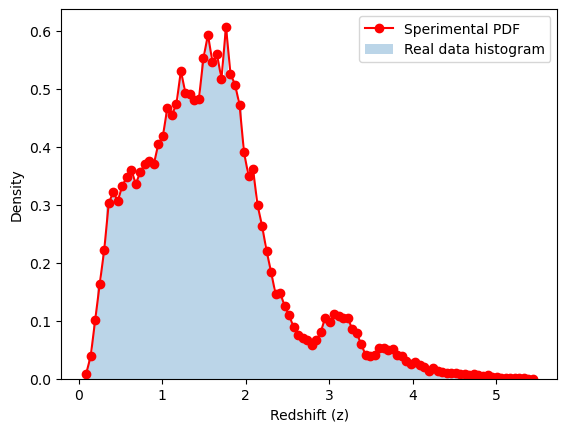

In [12]:
counts, bins = np.histogram(z, bins=100, density=True)
bin_centers = (bins[:-1] + bins[1:]) / 2


f_z = get_experimental_pdf(counts, bin_centers)

plt.plot(bin_centers, f_z(bin_centers), '-', marker='o', color='red', label='Sperimental PDF')
plt.hist(z, bins=100, density=True, alpha=0.3, label='Real data histogram')
plt.xlabel('Redshift (z)')
plt.ylabel('Density')
plt.legend()
plt.show()

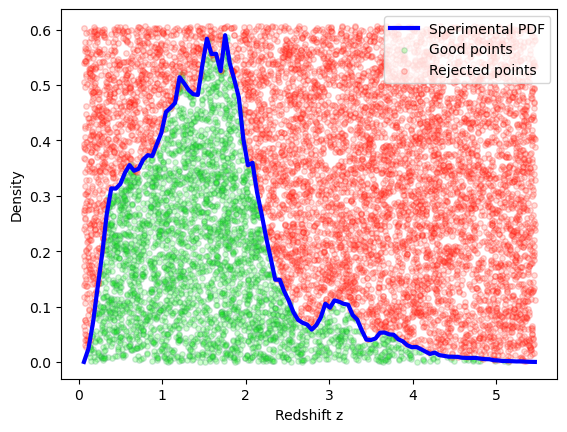

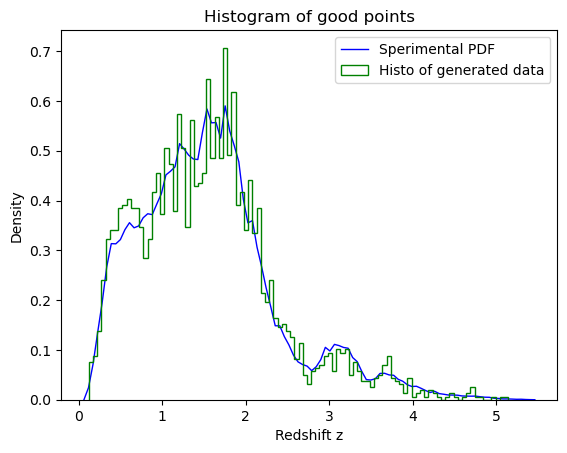

In [29]:
N=10000

z_uni = np.linspace(np.min(z),np.max(z),100)

plt.plot(z_uni,f_z(z_uni),  '-',  color='blue', label='Sperimental PDF', linewidth='3.')


ymax = np.max(f_z(bin_centers))
x = np.random.uniform(np.min(z),np.max(z),N)
y = np.random.uniform(0,ymax,N)
plt.scatter(x[y<f_z(x)],y[y<f_z(x)],c='lime', alpha=0.2, s=15., edgecolors='seagreen', label='Good points')
plt.scatter(x[y>f_z(x)],y[y>f_z(x)],c='tomato', alpha=0.2, s=15., edgecolors='red', label='Rejected points')
plt.xlabel('Redshift z')
plt.ylabel('Density')
plt.legend()
plt.show()
goodpoints = x[y<f_z(x)]

plt.plot(z_uni,f_z(z_uni),  '-',  color='blue', label='Sperimental PDF', linewidth='1.')
plt.hist(goodpoints,bins=100,density=True,histtype='step',color='green', label='Histo of generated data')
plt.xlabel('Redshift z')
plt.ylabel('Density')
plt.title('Histogram of good points')
plt.legend()
plt.show()

In [41]:
z_grid = np.linspace(z.min(), z.max(), 1000)
pdf_values = f_z(z_grid)

# 2. Calcoliamo la CDF numerica (integrale della PDF)
# Usiamo cumsum e moltiplichiamo per lo step (dx) per l'integrale
dz = z_grid[1] - z_grid[0]  # La larghezza di ogni intervallino nella griglia
cdf_values = np.cumsum(pdf_values) * dz
cdf_values /= cdf_values[-1]  # Normalizzazione forzata: la CDF deve finire a 1.0

Text(0, 0.5, 'cdf(z)')

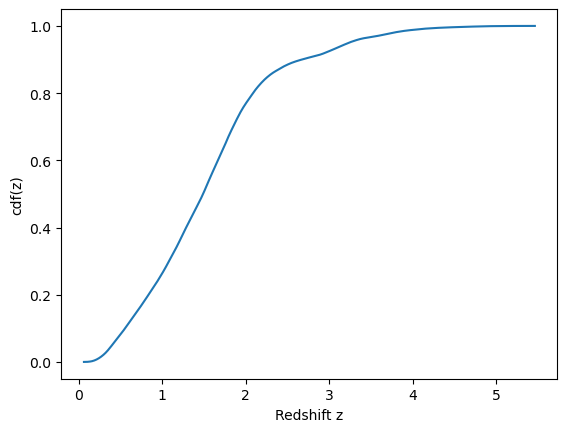

In [42]:
plt.plot(z_grid, cdf_values, '-')
plt.xlabel('Redshift z')
plt.ylabel('cdf(z)')

In [69]:
from scipy.interpolate import interp1d
cdf_func= interp1d(z_grid, cdf_values, kind='linear', bounds_error=False, fill_value="extrapolate")
# Invertiamo i ruoli: x è la probabilità (0-1), y è il redshift (z)
quantile_func = interp1d(cdf_values, z_grid, kind='linear', bounds_error=False, fill_value="extrapolate")


In [65]:
# Numero di punti che vogliamo generare (es. 5000)
n_upsampled = 10000
u = np.random.uniform(0, 1, n_upsampled)

# Trasformazione inversa
z_new = quantile_func(u)

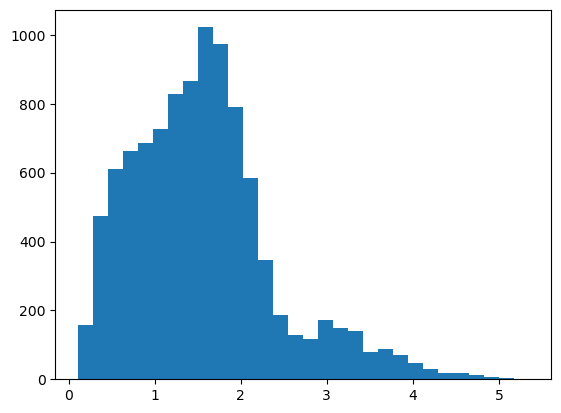

In [70]:
eps = np.random.uniform(0,1,10000)

# Using a vanilla root finder, which solves for cdf(h)=eps i.e. finds the zero of the function cdf(x)-eps
# La logica corretta per brentq: cerchi dove CDF(h) - e = 0
samples = [ brentq(lambda h: cdf_func(h) - e, np.min(z), np.max(z)) for e in eps]

plt.hist(samples,bins=30);

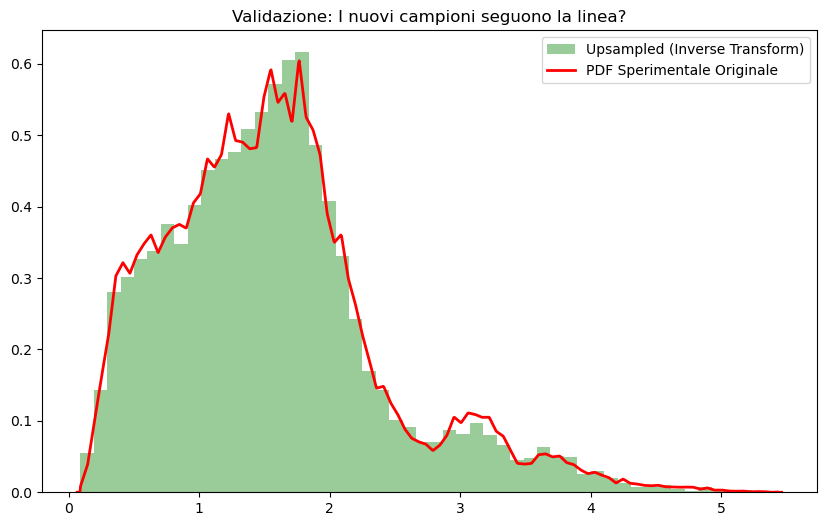

In [58]:
plt.figure(figsize=(10, 6))
plt.hist(z_new, bins=50, density=True, alpha=0.4, color='green', label='Upsampled (Inverse Transform)')
plt.plot(z_grid, pdf_values, 'r-', lw=2, label='PDF Sperimentale Originale')
plt.legend()
plt.title('Validazione: I nuovi campioni seguono la linea?')
plt.show()